## 1. imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [5]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

In [6]:
from sklearn.metrics import precision_recall_curve

In [7]:
from sklearn.model_selection import RandomizedSearchCV

In [8]:
# %pip install shap

In [9]:
import shap

c:\Users\Sarwani\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [152]:
import joblib
from pathlib import Path

In [159]:
from pathlib import Path

import joblib
from fastapi import FastAPI
from pydantic import BaseModel


## 2. load data

In [10]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "credit_card_default.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Dataset overview

In [11]:
df.shape

(30000, 24)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


## 4. Data Quality

### 1. Missing Data

In [14]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [15]:
df.duplicated().sum()

np.int64(35)

### 2. unique values

In [16]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

X1: 81 unique values
X2: 2 unique values
X3: 7 unique values
X4: 4 unique values
X5: 56 unique values
X6: 11 unique values
X7: 11 unique values
X8: 11 unique values
X9: 11 unique values
X10: 10 unique values
X11: 10 unique values
X12: 22723 unique values
X13: 22346 unique values
X14: 22026 unique values
X15: 21548 unique values
X16: 21010 unique values
X17: 20604 unique values
X18: 7943 unique values
X19: 7899 unique values
X20: 7518 unique values
X21: 6937 unique values
X22: 6897 unique values
X23: 6939 unique values
Y: 2 unique values


## 5. Target Investigation

In [17]:
df["Y"].value_counts()

Y
0    23364
1     6636
Name: count, dtype: int64

In [18]:
df["Y"].value_counts(normalize=True) * 100

Y
0    77.88
1    22.12
Name: proportion, dtype: float64

In [19]:
target_distribution = (
    df["Y"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

target_distribution

Y
0    77.88
1    22.12
Name: proportion, dtype: float64

## 6. Inspecting categorical distributions

### 6.1 Value Distributions

In [20]:
categorical_columns = ["X2", "X3", "X4"]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts().sort_index())


X2
X2
1    11888
2    18112
Name: count, dtype: int64

X3
X3
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

X4
X4
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


### 6.2 Visualize categorical distributions

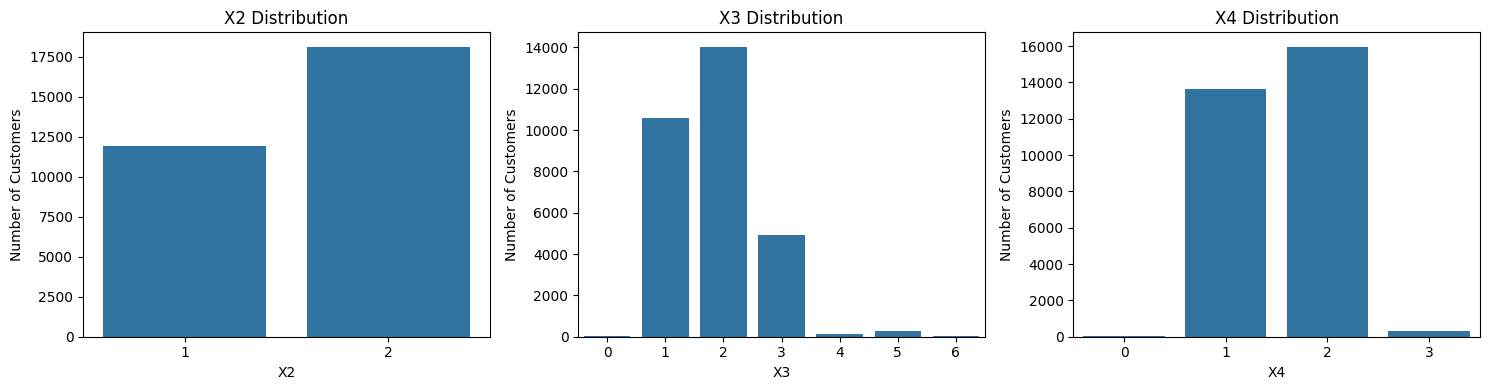

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, categorical_columns):
    sns.countplot(data=df, x=column, ax=ax)
    ax.set_title(f"{column} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### 6.3 Categorical features vs default

In [22]:
for column in categorical_columns:
    default_by_category = (
        df.groupby(column)["Y"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "default_rate"})
    )

    default_by_category["default_rate"] *= 100

    print(f"\n{column} vs Default")
    display(default_by_category)


X2 vs Default


,count,default_rate
X2,,
1,11888,24.167227
2,18112,20.776281



X3 vs Default


,count,default_rate
X3,,
0,14,0.000000
1,10585,19.234766
2,14030,23.734854
3,4917,25.157616
4,123,5.691057
5,280,6.428571
6,51,15.686275



X4 vs Default


,count,default_rate
X4,,
0,54,9.259259
1,13659,23.471704
2,15964,20.928339
3,323,26.006192


### 6.4 Visualize default rate

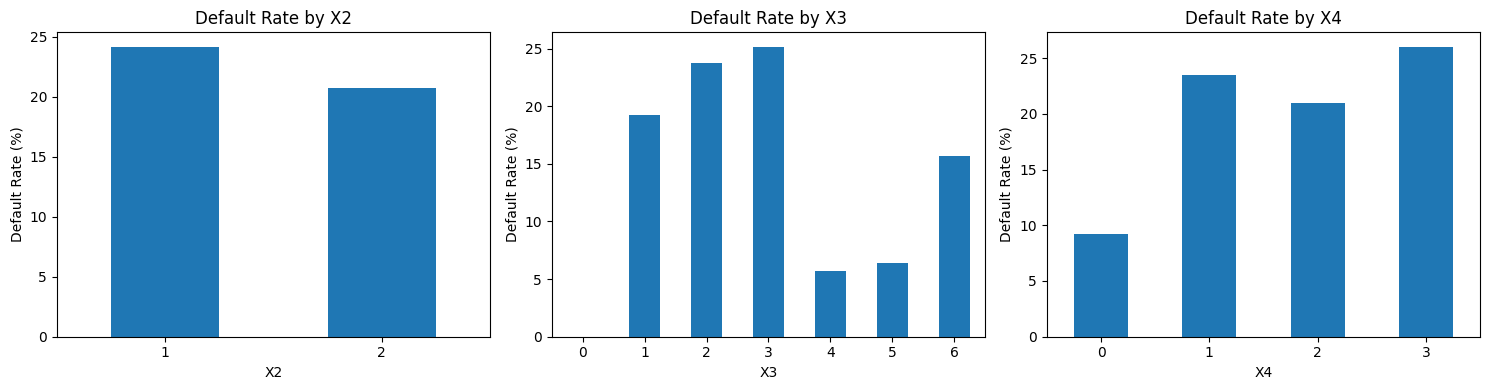

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, categorical_columns):
    default_rate = df.groupby(column)["Y"].mean().mul(100)

    default_rate.plot(kind="bar", ax=ax)

    ax.set_title(f"Default Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Default Rate (%)")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 7. Repayment Behavior

In [24]:
repayment_columns = ["X6", "X7", "X8", "X9", "X10", "X11"]

### 7.1 Distribution of repayment statuses

In [25]:
for column in repayment_columns:
    print(f"\n{column}")
    print(df[column].value_counts().sort_index())


X6
X6
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

X7
X7
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

X8
X8
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

X9
X9
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

X10
X10
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

X11
X11
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64


### 7.2 Visualize repayment behavior

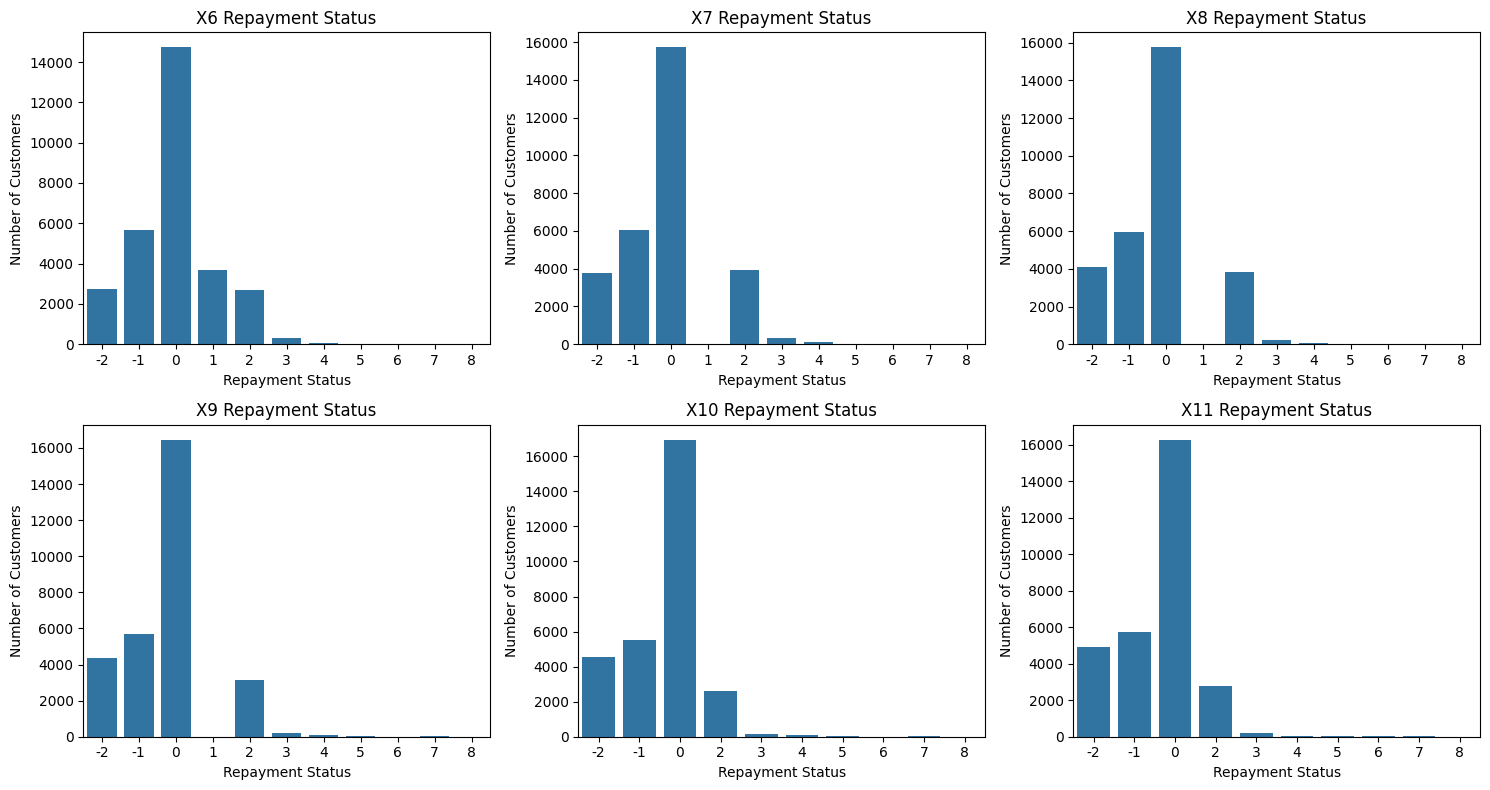

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flatten(), repayment_columns):
    sns.countplot(data=df, x=column, ax=ax)
    ax.set_title(f"{column} Repayment Status")
    ax.set_xlabel("Repayment Status")
    ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### 7.3 Repayment status vs default

In [27]:
for column in repayment_columns:
    default_rate = (
        df.groupby(column)["Y"]
        .mean()
        .mul(100)
    )

    print(f"\n{column} - Default Rate (%)")
    display(default_rate)


X6 - Default Rate (%)


X6
-2    13.229431
-1    16.778051
 0    12.811291
 1    33.947939
 2    69.141357
 3    75.776398
 4    68.421053
 5    50.000000
 6    54.545455
 7    77.777778
 8    57.894737
Name: Y, dtype: float64


X7 - Default Rate (%)


X7
-2    18.270756
-1    15.966942
 0    15.912270
 1    17.857143
 2    55.614973
 3    61.656442
 4    50.505051
 5    60.000000
 6    75.000000
 7    60.000000
 8     0.000000
Name: Y, dtype: float64


X8 - Default Rate (%)


X8
-2    18.531212
-1    15.594476
 0    17.451155
 1    25.000000
 2    51.557999
 3    57.500000
 4    57.894737
 5    57.142857
 6    60.869565
 7    81.481481
 8    66.666667
Name: Y, dtype: float64


X9 - Default Rate (%)


X9
-2    19.250230
-1    15.895903
 0    18.328775
 1    50.000000
 2    52.326686
 3    61.111111
 4    66.666667
 5    51.428571
 6    40.000000
 7    82.758621
 8    50.000000
Name: Y, dtype: float64


X10 - Default Rate (%)


X10
-2     19.687637
-1     16.194259
 0     18.852894
 2     54.188880
 3     63.483146
 4     60.714286
 5     58.823529
 6     75.000000
 7     82.758621
 8    100.000000
Name: Y, dtype: float64


X11 - Default Rate (%)


X11
-2     20.040858
-1     16.986063
 0     18.844406
 2     50.650759
 3     64.130435
 4     63.265306
 5     53.846154
 6     73.684211
 7     82.608696
 8    100.000000
Name: Y, dtype: float64

### 7.4 Plot default rate by repayment status

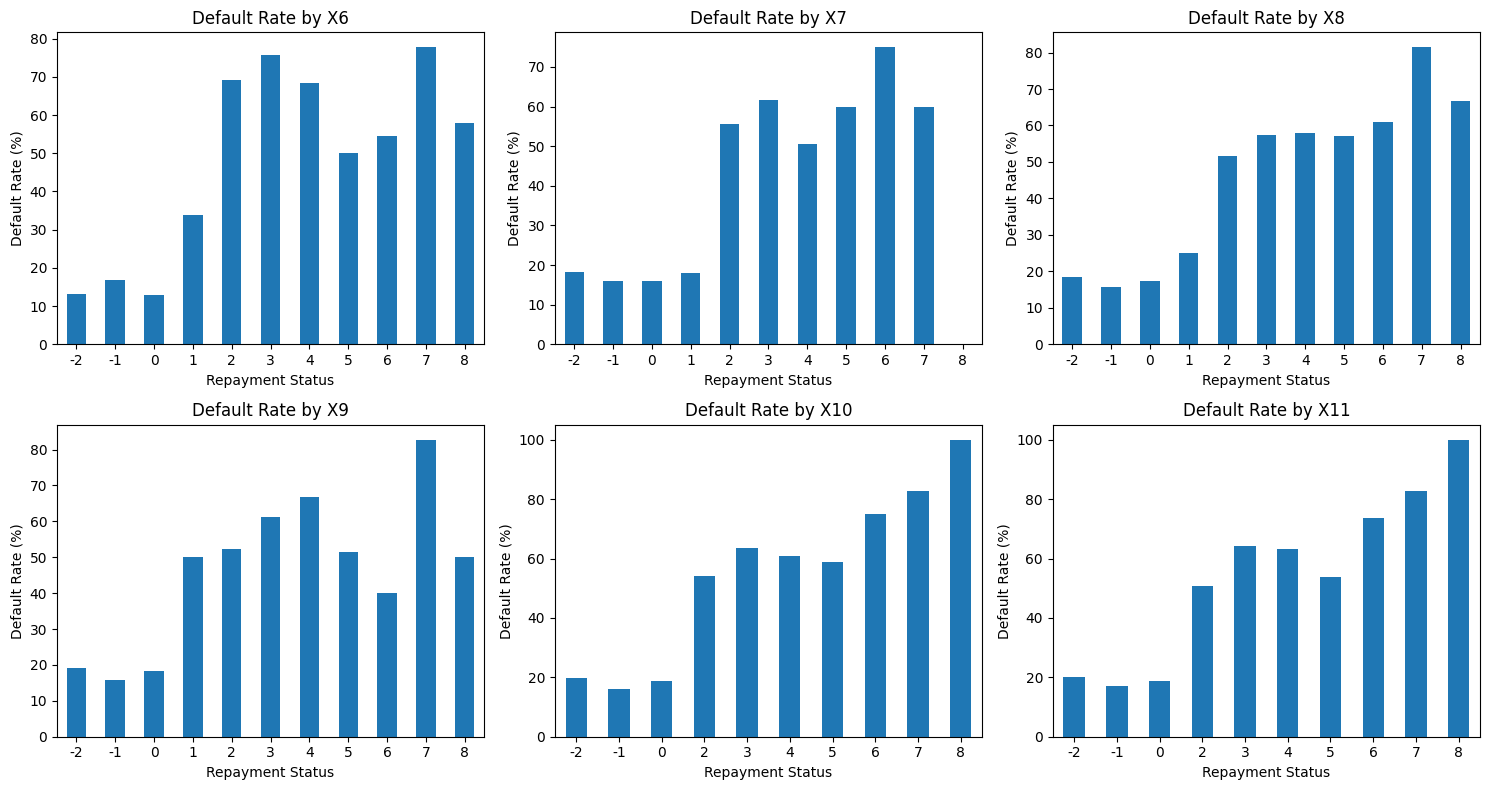

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flatten(), repayment_columns):
    default_rate = df.groupby(column)["Y"].mean().mul(100)

    default_rate.plot(kind="bar", ax=ax)

    ax.set_title(f"Default Rate by {column}")
    ax.set_xlabel("Repayment Status")
    ax.set_ylabel("Default Rate (%)")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 7.5 Default rate across months

In [29]:
monthly_default_rates = {}

for column in repayment_columns:
    monthly_default_rates[column] = df.groupby(column)["Y"].mean().mean()

monthly_default_rates

{'X6': np.float64(0.48211226320026496),
 'X7': np.float64(0.3916214329573217),
 'X8': np.float64(0.46335468123731727),
 'X9': np.float64(0.46160596721048874),
 'X10': np.float64(0.5497032530022026),
 'X11': np.float64(0.5440568871234334)}

## 8. Credit Limit Analysis

### 8.1 Overall distribution

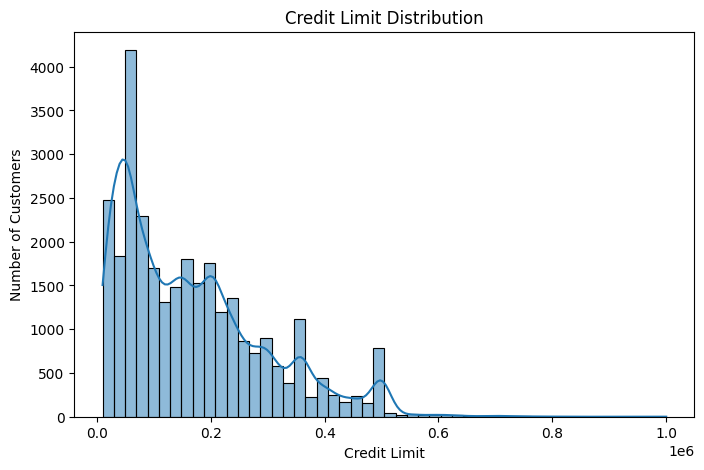

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="X1", bins=50, kde=True)

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.show()

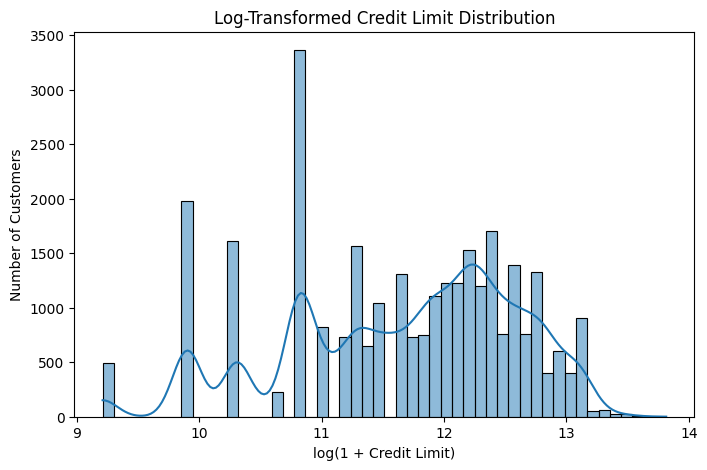

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(np.log1p(df["X1"]), bins=50, kde=True)

plt.title("Log-Transformed Credit Limit Distribution")
plt.xlabel("log(1 + Credit Limit)")
plt.ylabel("Number of Customers")

plt.show()

### 8.2 Credit limit vs default

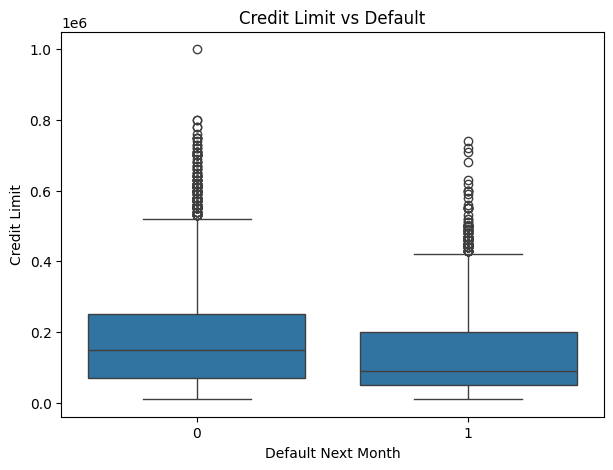

In [32]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="Y", y="X1")

plt.title("Credit Limit vs Default")
plt.xlabel("Default Next Month")
plt.ylabel("Credit Limit")

plt.show()

### 8.3 Summary statistics by target

In [33]:
credit_limit_by_default = (
    df.groupby("Y")["X1"]
    .describe()
)

credit_limit_by_default

,count,mean,std,min,25%,50%,75%,max
Y,,,,,,,,
0,23364.0,178099.726074,131628.359660,10000.0,70000.0,150000.0,250000.0,1000000.0
1,6636.0,130109.656420,115378.540571,10000.0,50000.0,90000.0,200000.0,740000.0


### 8.4 Default rate by credit-limit bands

In [34]:
df["credit_limit_band"] = pd.qcut(
    df["X1"],
    q=5,
    duplicates="drop"
)

credit_limit_default_rate = (
    df.groupby("credit_limit_band", observed=True)["Y"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "default_rate"})
)

credit_limit_default_rate["default_rate"] *= 100

credit_limit_default_rate

,count,default_rate
credit_limit_band,,
"(9999.999, 50000.0]",7676,31.787389
"(50000.0, 100000.0]",4822,25.798424
"(100000.0, 180000.0]",6123,19.859546
"(180000.0, 270000.0]",5421,16.860358
"(270000.0, 1000000.0]",5958,13.796576


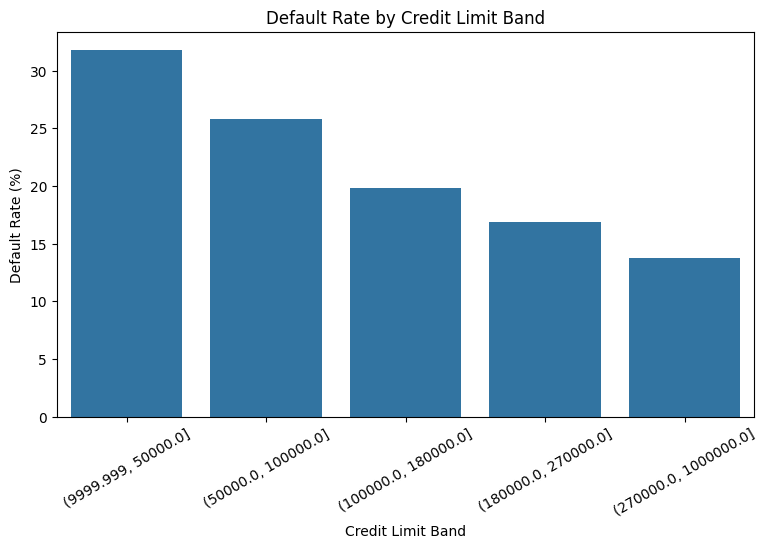

In [35]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=credit_limit_default_rate.reset_index(),
    x="credit_limit_band",
    y="default_rate"
)

plt.title("Default Rate by Credit Limit Band")
plt.xlabel("Credit Limit Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.show()

## 9. Age Analysis

### 9.1 Age distribution

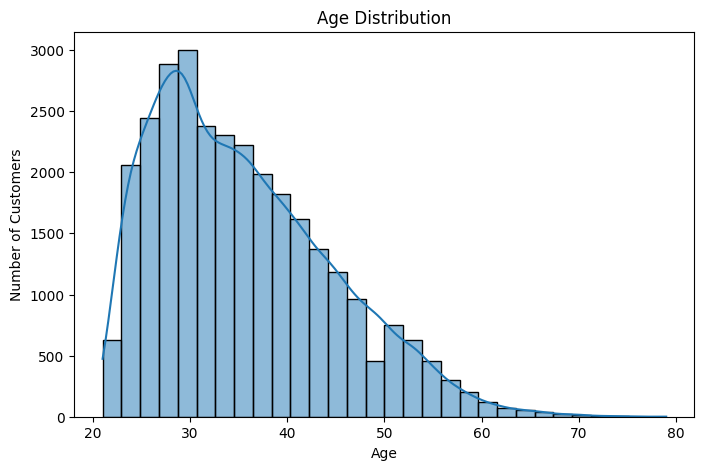

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="X5", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### 9.2 Age vs default

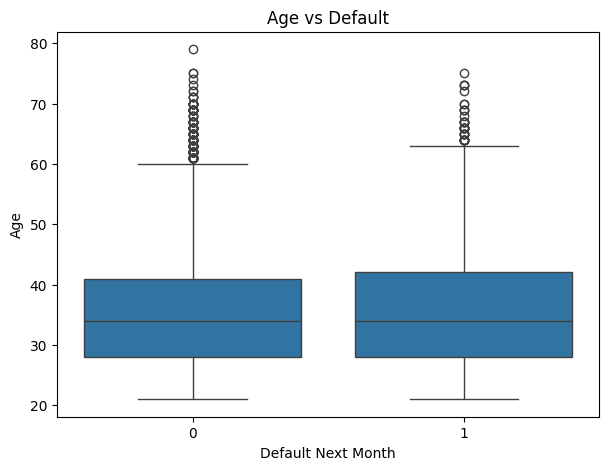

In [37]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="Y", y="X5")

plt.title("Age vs Default")
plt.xlabel("Default Next Month")
plt.ylabel("Age")

plt.show()

### 9.3 Age summary by target

In [38]:
age_by_default = (
    df.groupby("Y")["X5"]
    .describe()
)

age_by_default

,count,mean,std,min,25%,50%,75%,max
Y,,,,,,,,
0,23364.0,35.417266,9.077355,21.0,28.0,34.0,41.0,79.0
1,6636.0,35.725738,9.693438,21.0,28.0,34.0,42.0,75.0


### 9.4 Default rate by age group

In [39]:
df["age_band"] = pd.cut(
    df["X5"],
    bins=[20, 25, 30, 35, 40, 50, 60, 80],
    right=False
)

age_default_rate = (
    df.groupby("age_band", observed=True)["Y"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "default_rate"})
)

age_default_rate["default_rate"] *= 100

age_default_rate

,count,default_rate
age_band,,
"[20, 25)",2685,27.188082
"[25, 30)",6933,21.159671
"[30, 35)",6078,19.315564
"[35, 40)",5160,21.356589
"[40, 50)",6464,22.973391
"[50, 60)",2341,24.861170
"[60, 80)",339,28.318584


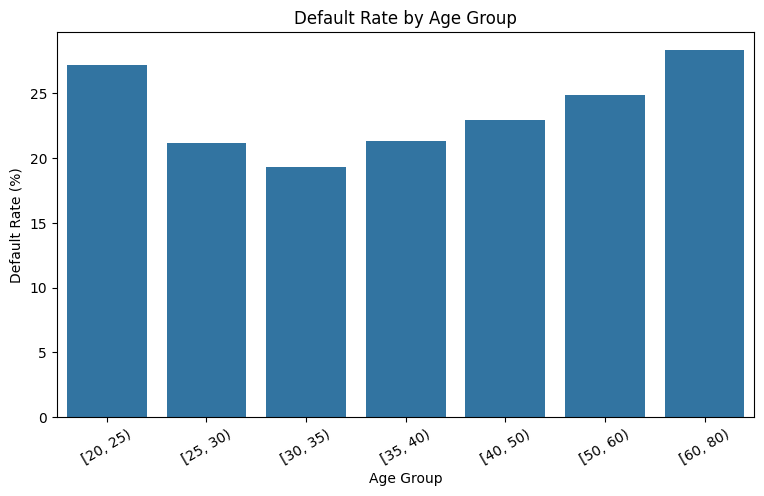

In [40]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_default_rate.reset_index(),
    x="age_band",
    y="default_rate"
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.show()

## 10. Data cleanup

### 10.1 Check missing values

In [41]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [42]:
missing_percentage = (
    df.isnull().mean() * 100
)

missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

### 10.2 Investigate duplicate records

In [43]:
df.duplicated().sum()

np.int64(35)

In [44]:
duplicates = df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

duplicates.head(20)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X17,X18,X19,X20,X21,X22,X23,Y,credit_limit_band,age_band
12430,20000,1,2,2,24,2,2,4,4,4,...,1650,0,0,0,0,0,0,1,"(9999.999, 50000.0]","[20, 25)"
14294,20000,1,2,2,24,2,2,4,4,4,...,1650,0,0,0,0,0,0,1,"(9999.999, 50000.0]","[20, 25)"
1759,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,"(9999.999, 50000.0]","[25, 30)"
10250,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,"(9999.999, 50000.0]","[25, 30)"
7170,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,"(9999.999, 50000.0]","[20, 25)"
17032,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,"(9999.999, 50000.0]","[20, 25)"
7366,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[30, 35)"
19114,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[30, 35)"
21768,80000,2,2,2,25,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[25, 30)"
27765,80000,2,2,2,25,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[25, 30)"


In [45]:
duplicate_counts = (
    duplicates
    .value_counts()
    .reset_index(name="count")
)

duplicate_counts.head(20)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X18,X19,X20,X21,X22,X23,Y,credit_limit_band,age_band,count
0,20000,1,2,2,24,2,2,4,4,4,...,0,0,0,0,0,0,1,"(9999.999, 50000.0]","[20, 25)",2
1,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(9999.999, 50000.0]","[25, 30)",2
2,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(9999.999, 50000.0]","[20, 25)",2
3,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[30, 35)",2
4,80000,2,2,2,25,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[25, 30)",2
5,80000,2,3,1,42,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[40, 50)",2
6,90000,2,1,2,31,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[30, 35)",2
7,100000,2,2,1,49,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[40, 50)",2
8,110000,2,1,2,31,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(100000.0, 180000.0]","[30, 35)",2
9,140000,1,1,2,29,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(100000.0, 180000.0]","[25, 30)",2


In [46]:
duplicate_counts = (
    duplicates
    .value_counts()
    .reset_index(name="count")
)

duplicate_counts.head(20)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X18,X19,X20,X21,X22,X23,Y,credit_limit_band,age_band,count
0,20000,1,2,2,24,2,2,4,4,4,...,0,0,0,0,0,0,1,"(9999.999, 50000.0]","[20, 25)",2
1,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(9999.999, 50000.0]","[25, 30)",2
2,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(9999.999, 50000.0]","[20, 25)",2
3,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[30, 35)",2
4,80000,2,2,2,25,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[25, 30)",2
5,80000,2,3,1,42,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[40, 50)",2
6,90000,2,1,2,31,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[30, 35)",2
7,100000,2,2,1,49,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(50000.0, 100000.0]","[40, 50)",2
8,110000,2,1,2,31,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(100000.0, 180000.0]","[30, 35)",2
9,140000,1,1,2,29,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,"(100000.0, 180000.0]","[25, 30)",2


### 10.3 Check whether duplicates have conflicting targets

In [47]:
duplicate_target_check = (
    duplicates
    .groupby(list(df.columns[:-1]), observed=True)["Y"]
    .nunique()
)

duplicate_target_check.value_counts()

Y
1    35
Name: count, dtype: int64

### 10.4 Decision on duplicates

### Duplicate Handling

The dataset contains 35 exact duplicate rows. Since the dataset does not provide a unique customer identifier, identical feature records cannot be assumed to represent duplicate customers.

Therefore, the duplicate observations are retained for modeling. Their presence is documented as a data-quality consideration rather than treating them as confirmed duplicate customers.

### 10.5 Validate categorical values

In [48]:
categorical_columns = ["X2", "X3", "X4"]

for column in categorical_columns:
    print(f"\n{column}")
    print(sorted(df[column].unique()))


X2
[np.int64(1), np.int64(2)]

X3
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

X4
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### 10.6 Validate repayment-status values

In [49]:
repayment_columns = ["X6", "X7", "X8", "X9", "X10", "X11"]

repayment_unique_values = {
    column: sorted(df[column].unique())
    for column in repayment_columns
}

repayment_unique_values

{'X6': [np.int64(-2),
  np.int64(-1),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8)],
 'X7': [np.int64(-2),
  np.int64(-1),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8)],
 'X8': [np.int64(-2),
  np.int64(-1),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8)],
 'X9': [np.int64(-2),
  np.int64(-1),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8)],
 'X10': [np.int64(-2),
  np.int64(-1),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8)],
 'X11': [np.int64(-2),
  np.int64(-1),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),


### 10.7 Check for impossible ages

In [50]:
df["X5"].min(), df["X5"].max()

(np.int64(21), np.int64(79))

In [51]:
invalid_age = df[
    (df["X5"] < 18) |
    (df["X5"] > 100)
]

invalid_age.shape

(0, 26)

### 10.8 Check credit limits

In [52]:
invalid_credit_limit = df[df["X1"] <= 0]

invalid_credit_limit.shape

(0, 26)

### 10.9 Check bill and payment amounts

In [53]:
bill_columns = [
    "X12", "X13", "X14",
    "X15", "X16", "X17"
]

payment_columns = [
    "X18", "X19", "X20",
    "X21", "X22", "X23"
]

In [54]:
negative_payment_counts = (
    df[payment_columns] < 0
).sum()

negative_payment_counts

X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
dtype: int64

### 10.10 Remove temporary EDA columns

In [55]:
df.drop(
    columns=["credit_limit_band", "age_band"],
    inplace=True
)

### 10.11 Final cleanup validation

In [56]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Columns:", df.columns.tolist())

Shape: (30000, 24)
Missing values: 0
Duplicate rows: 35
Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


### 10.12 Save the cleaned dataset

In [57]:
PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "credit_card_default_cleaned.csv"
)

df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Cleaned dataset saved to: {PROCESSED_DATA_PATH}")

Cleaned dataset saved to: d:\credit-risk-ml-platform\data\processed\credit_card_default_cleaned.csv


## 11. Feature Engineering

### 11.1 Rename columns

In [58]:
df = df.rename(columns={
    "X1": "credit_limit",
    "X2": "gender",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",
    "X6": "repay_sep",
    "X7": "repay_aug",
    "X8": "repay_jul",
    "X9": "repay_jun",
    "X10": "repay_may",
    "X11": "repay_apr",
    "X12": "bill_sep",
    "X13": "bill_aug",
    "X14": "bill_jul",
    "X15": "bill_jun",
    "X16": "bill_may",
    "X17": "bill_apr",
    "X18": "payment_sep",
    "X19": "payment_aug",
    "X20": "payment_jul",
    "X21": "payment_jun",
    "X22": "payment_may",
    "X23": "payment_apr",
    "Y": "default"
})

### 11.2 Credit utilization features

In [59]:
bill_columns = [
    "bill_sep",
    "bill_aug",
    "bill_jul",
    "bill_jun",
    "bill_may",
    "bill_apr"
]

df["avg_bill_amount"] = df[bill_columns].mean(axis=1)

In [60]:
df["max_bill_amount"] = df[bill_columns].max(axis=1)

df["min_bill_amount"] = df[bill_columns].min(axis=1)

###  11.3 Repayment behavior features

In [61]:
repayment_columns = [
    "repay_sep",
    "repay_aug",
    "repay_jul",
    "repay_jun",
    "repay_may",
    "repay_apr"
]

In [62]:
df["max_repayment_status"] = df[repayment_columns].max(axis=1)

In [63]:
df["avg_repayment_status"] = df[repayment_columns].mean(axis=1)

In [64]:
df["months_serious_delay"] = (
    df[repayment_columns] >= 2
).sum(axis=1)


df["months_with_delay"] = (
    df[repayment_columns] > 0
).sum(axis=1)

In [65]:
# Most recent repayment status

# September is the most recent month in this dataset:

df["recent_repayment_status"] = df["repay_sep"]

### 11.4 Bill amount features

In [66]:
df["total_bill_amount"] = df[bill_columns].sum(axis=1)

df["bill_amount_std"] = df[bill_columns].std(axis=1)

### 11.5 Payment behavior features

In [67]:
payment_columns = [
    "payment_sep",
    "payment_aug",
    "payment_jul",
    "payment_jun",
    "payment_may",
    "payment_apr"
]

In [68]:
df["total_payment_amount"] = df[payment_columns].sum(axis=1)

df["avg_payment_amount"] = df[payment_columns].mean(axis=1)

df["max_payment_amount"] = df[payment_columns].max(axis=1)

###  11.6 Payment-to-bill features

In [69]:
df["payment_to_bill_ratio"] = (
    df["total_payment_amount"] /
    df["total_bill_amount"].replace(0, np.nan)
)

In [70]:
### check for 0 bill
df["payment_to_bill_ratio"].describe()

count    29130.000000
mean         0.392318
std          7.784430
min       -546.928571
25%          0.042188
50%          0.092133
75%          0.615363
max        797.000000
Name: payment_to_bill_ratio, dtype: float64

In [71]:
## 0 denominators
df["payment_to_bill_ratio"].isnull().sum()

np.int64(870)

### 11.7 Age and demographic features

In [72]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[20, 30, 40, 50, 60, 80],
    labels=[
        "21-29",
        "30-39",
        "40-49",
        "50-59",
        "60+"
    ],
    right=False
)

### 11.8 Feature engineering validation

In [73]:
print("Shape:", df.shape)

df.head()

Shape: (30000, 39)


,credit_limit,gender,education,marital_status,age,repay_sep,repay_aug,repay_jul,repay_jun,repay_may,...,months_serious_delay,months_with_delay,recent_repayment_status,total_bill_amount,bill_amount_std,total_payment_amount,avg_payment_amount,max_payment_amount,payment_to_bill_ratio,age_group
0,20000,2,2,1,24,2,2,-1,-1,-2,...,2,2,2,7704,1761.633219,689,114.833333,689,0.089434,21-29
1,120000,2,2,2,26,-1,2,0,0,0,...,2,2,-1,17077,637.967841,5000,833.333333,2000,0.292791,21-29
2,90000,2,2,2,34,0,0,0,0,0,...,0,0,0,101653,6064.518593,11018,1836.333333,5000,0.108388,30-39
3,50000,2,2,1,37,0,0,0,0,0,...,0,0,0,231334,10565.793518,8388,1398.000000,2019,0.036259,30-39
4,50000,1,2,1,57,-1,0,-1,0,0,...,0,0,-1,109339,10668.590074,59049,9841.500000,36681,0.540054,50-59


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   credit_limit             30000 non-null  int64   
 1   gender                   30000 non-null  int64   
 2   education                30000 non-null  int64   
 3   marital_status           30000 non-null  int64   
 4   age                      30000 non-null  int64   
 5   repay_sep                30000 non-null  int64   
 6   repay_aug                30000 non-null  int64   
 7   repay_jul                30000 non-null  int64   
 8   repay_jun                30000 non-null  int64   
 9   repay_may                30000 non-null  int64   
 10  repay_apr                30000 non-null  int64   
 11  bill_sep                 30000 non-null  int64   
 12  bill_aug                 30000 non-null  int64   
 13  bill_jul                 30000 non-null  int64   
 14  bill_j

In [75]:
engineered_features = [
    "avg_bill_amount",
    "max_bill_amount",
    "min_bill_amount",
    "max_repayment_status",
    "avg_repayment_status",
    "months_serious_delay",
    "months_with_delay",
    "recent_repayment_status",
    "total_bill_amount",
    "bill_amount_std",
    "total_payment_amount",
    "avg_payment_amount",
    "max_payment_amount",
    "payment_to_bill_ratio",
    "age_group"
]

df[engineered_features].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
avg_bill_amount,30000.0,NaN,NaN,NaN,44976.9452,63260.72186,-56043.166667,4781.333333,21051.833333,57104.416667,877313.833333
max_bill_amount,30000.0,NaN,NaN,NaN,60572.436867,78404.814025,-6029.0,10060.0,31208.5,79599.0,1664089.0
min_bill_amount,30000.0,NaN,NaN,NaN,31722.2108,54719.577753,-339603.0,0.0,8664.5,39180.5,551702.0
max_repayment_status,30000.0,NaN,NaN,NaN,0.438733,1.345154,-2.0,0.0,0.0,2.0,8.0
avg_repayment_status,30000.0,NaN,NaN,NaN,-0.182439,0.982176,-2.0,-0.833333,0.0,0.0,6.0
months_serious_delay,30000.0,NaN,NaN,NaN,0.710133,1.464712,0.0,0.0,0.0,1.0,6.0
months_with_delay,30000.0,NaN,NaN,NaN,0.8342,1.554303,0.0,0.0,0.0,1.0,6.0
recent_repayment_status,30000.0,NaN,NaN,NaN,-0.0167,1.123802,-2.0,-1.0,0.0,0.0,8.0
total_bill_amount,30000.0,NaN,NaN,NaN,269861.6712,379564.331162,-336259.0,28688.0,126311.0,342626.5,5263883.0
bill_amount_std,30000.0,NaN,NaN,NaN,12077.787549,20302.149149,0.0,1549.935213,4579.662158,14352.259579,647788.051081


## 12. Feature/Target Separation + Train/Test Split

### 12.1 Define features and target

In [76]:
TARGET = "default"

### 12.2 Separate X and y

In [77]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [78]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30000, 38)
Target shape: (30000,)


### 12.3 Identify numerical and categorical features

In [79]:
categorical_features = [
    "gender",
    "education",
    "marital_status",
    "age_group"
]

In [80]:
numerical_features = [
    column
    for column in X.columns
    if column not in categorical_features
]

In [81]:
print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'education', 'marital_status', 'age_group']

Numerical features:
['credit_limit', 'age', 'repay_sep', 'repay_aug', 'repay_jul', 'repay_jun', 'repay_may', 'repay_apr', 'bill_sep', 'bill_aug', 'bill_jul', 'bill_jun', 'bill_may', 'bill_apr', 'payment_sep', 'payment_aug', 'payment_jul', 'payment_jun', 'payment_may', 'payment_apr', 'avg_bill_amount', 'max_bill_amount', 'min_bill_amount', 'max_repayment_status', 'avg_repayment_status', 'months_serious_delay', 'months_with_delay', 'recent_repayment_status', 'total_bill_amount', 'bill_amount_std', 'total_payment_amount', 'avg_payment_amount', 'max_payment_amount', 'payment_to_bill_ratio']


### 12.4 Train/test split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


### 12.5 Validate the split

In [83]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24000, 38)
X_test: (6000, 38)
y_train: (24000,)
y_test: (6000,)


In [84]:
print("Training default rate:")
print(y_train.value_counts(normalize=True).sort_index().mul(100))

print("\nTest default rate:")
print(y_test.value_counts(normalize=True).sort_index().mul(100))

Training default rate:
default
0    77.879167
1    22.120833
Name: proportion, dtype: float64

Test default rate:
default
0    77.883333
1    22.116667
Name: proportion, dtype: float64


In [85]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Total rows:", len(X_train) + len(X_test))

Training rows: 24000
Testing rows: 6000
Total rows: 30000


## 13. Preprocessing Pipeline

### 13.1 Import preprocessing tools


In [86]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### 13.2 Define numerical preprocessing


In [87]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Why median?

Credit/financial datasets can contain extreme values. Median imputation is less sensitive to outliers than mean imputation.

And scaling is important particularly for our Logistic Regression baseline.

### 13.3 Define categorical preprocessing


In [88]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

### 13.4 Build ColumnTransformer


In [89]:
preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

### 13.5 Fit and transform training data


In [90]:
X_train_processed = preprocessor.fit_transform(X_train)

print("Processed training shape:", X_train_processed.shape)

Processed training shape: (24000, 52)


### 13.6 Transform test data


In [91]:
X_test_processed = preprocessor.transform(X_test)

print("Processed testing shape:", X_test_processed.shape)

Processed testing shape: (6000, 52)


### 13.7 Validate processed data

In [92]:
print(
    "NaN values in training:",
    np.isnan(X_train_processed.toarray()).sum()
    if hasattr(X_train_processed, "toarray")
    else np.isnan(X_train_processed).sum()
)

print(
    "NaN values in testing:",
    np.isnan(X_test_processed.toarray()).sum()
    if hasattr(X_test_processed, "toarray")
    else np.isnan(X_test_processed).sum()
)

NaN values in training: 0
NaN values in testing: 0


In [93]:
print("Original feature count:", X_train.shape[1])
print("Processed feature count:", X_train_processed.shape[1])

Original feature count: 38
Processed feature count: 52


## 14. Model Training

### 14.1 Evaluation function

In [94]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }

    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))

    print("\nMetrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    return metrics, y_pred, y_prob

Why PR-AUC?

Our default rate is about 22%, so accuracy alone can be misleading.

We'll pay particular attention to:

Recall
F1
ROC-AUC
PR-AUC

And because this is a credit-risk project, recall for the default class is particularly important: a false negative means predicting someone as non-default when they actually default.

### 14.2 Logistic Regression baseline


In [95]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [96]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [97]:
logistic_metrics, logistic_pred, logistic_prob = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.66      0.31      0.42      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.63      0.65      6000
weighted avg       0.79      0.81      0.78      6000


Metrics:
accuracy: 0.8120
precision: 0.6618
recall: 0.3067
f1: 0.4192
roc_auc: 0.7544
pr_auc: 0.5236


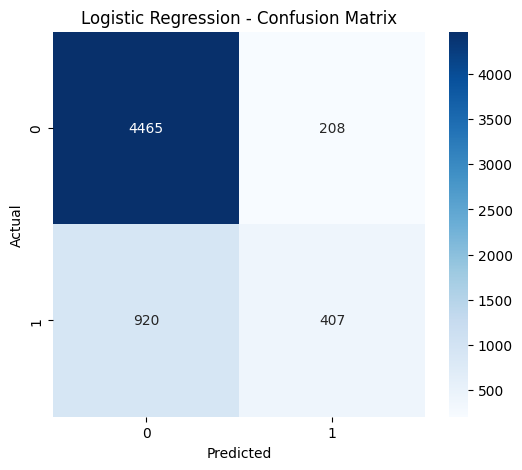

In [98]:
logistic_cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 14.3 Decision Tree


In [99]:
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        DecisionTreeClassifier(
            random_state=42,
            max_depth=6,
            min_samples_leaf=20
        )
    )
])

In [100]:
decision_tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [101]:
decision_tree_metrics, decision_tree_pred, decision_tree_prob = evaluate_model(
    decision_tree_model,
    X_test,
    y_test
)

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000


Metrics:
accuracy: 0.8158
precision: 0.6637
recall: 0.3391
f1: 0.4489
roc_auc: 0.7586
pr_auc: 0.5100


### 14.4 Random Forest

In [102]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [103]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [104]:
random_forest_metrics, random_forest_pred, random_forest_prob = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000


Metrics:
accuracy: 0.8182
precision: 0.6630
recall: 0.3617
f1: 0.4681
roc_auc: 0.7791
pr_auc: 0.5553


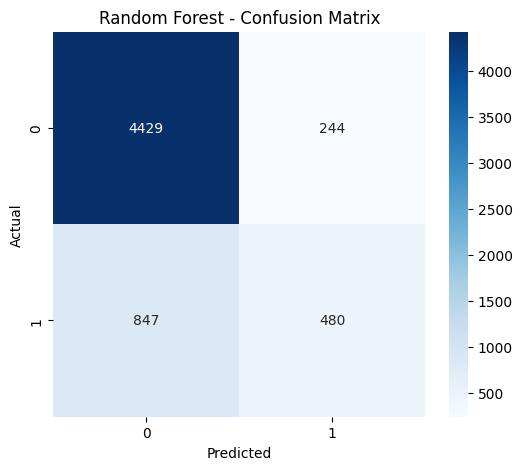

In [105]:
random_forest_cm = confusion_matrix(
    y_test,
    random_forest_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


### 14.5 Compare models

In [106]:
model_results = pd.DataFrame({
    "Logistic Regression": logistic_metrics,
    "Decision Tree": decision_tree_metrics,
    "Random Forest": random_forest_metrics
}).T

model_results

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.812000,0.661789,0.306707,0.419156,0.754410,0.523559
Decision Tree,0.815833,0.663717,0.339111,0.448878,0.758619,0.509974
Random Forest,0.818167,0.662983,0.361718,0.468064,0.779085,0.555262


In [107]:
model_results.sort_values(
    by="roc_auc",
    ascending=False
)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Random Forest,0.818167,0.662983,0.361718,0.468064,0.779085,0.555262
Decision Tree,0.815833,0.663717,0.339111,0.448878,0.758619,0.509974
Logistic Regression,0.812000,0.661789,0.306707,0.419156,0.754410,0.523559


### 14.6 Select model for further tuning

Random Forest is the natural candidate for further tuning based on these baseline results because on this test set it currently has the strongest combination of the metrics we're examining:

highest Recall: 36.17%

highest F1: 46.81%

highest ROC-AUC: 77.91%

highest PR-AUC: 55.53%

accuracy is also slightly higher.

The Decision Tree has marginally higher precision, but its recall, F1, ROC-AUC and PR-AUC are lower.


Random forest recall ~= 0.362
That means we're catching only about 36% of the actual defaults at the current 0.5 classification threshold. Since it cannot be directly accepted, class imbalance, probability thresholds must be examined and hyperparameter tuning must be done before final model selection.

## 15. Class Imbalance & Threshold Analysis.

### 15.1 Inspect class distribution

In [108]:
class_distribution = (
    y_train
    .value_counts()
    .sort_index()
)

class_percentage = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Training Class Distribution:")
print(class_distribution)

print("\nTraining Class Percentage:")
print(class_percentage)

Training Class Distribution:
default
0    18691
1     5309
Name: count, dtype: int64

Training Class Percentage:
default
0    77.879167
1    22.120833
Name: proportion, dtype: float64


### 15.2 Baseline threshold analysis

In [109]:
baseline_threshold = 0.50

baseline_pred = (
    random_forest_prob >= baseline_threshold
).astype(int)

baseline_cm = confusion_matrix(
    y_test,
    baseline_pred
)

print("Confusion Matrix at Threshold = 0.50")
print(baseline_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        baseline_pred
    )
)

Confusion Matrix at Threshold = 0.50
[[4429  244]
 [ 847  480]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



### 15.3 Precision-Recall Trade-off

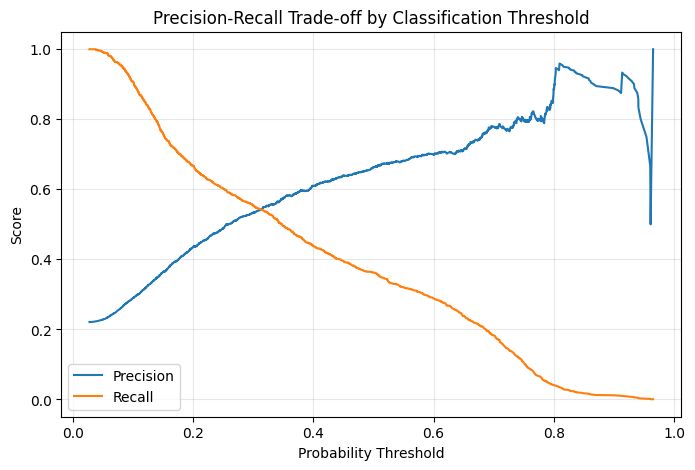

In [110]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    random_forest_prob
)

plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

What we're looking for

The classic trade-off is seen:

Lower threshold →

more customers classified as potential defaults
higher recall
lower precision
more false positives

Higher threshold →

fewer customers classified as potential defaults
lower recall
higher precision
fewer false positives

This is important for our project because 0.50 isn't automatically the correct business threshold.

### 15.4 Evaluate Multiple Thresholds

In [111]:
thresholds_to_test = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (
        random_forest_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "f1": f1_score(
            y_test,
            y_pred_threshold
        ),
        "roc_auc": roc_auc_score(
            y_test,
            random_forest_prob
        ),
        "pr_auc": average_precision_score(
            y_test,
            random_forest_prob
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df

,threshold,precision,recall,f1,roc_auc,pr_auc
0,0.20,0.434527,0.667671,0.526441,0.779085,0.555262
1,0.25,0.488088,0.602110,0.539136,0.779085,0.555262
2,0.30,0.533430,0.553127,0.543100,0.779085,0.555262
3,0.35,0.574301,0.495102,0.531769,0.779085,0.555262
4,0.40,0.609654,0.437830,0.509649,0.779085,0.555262
5,0.45,0.639024,0.394876,0.488123,0.779085,0.555262
6,0.50,0.662983,0.361718,0.468064,0.779085,0.555262
7,0.55,0.682183,0.320271,0.435897,0.779085,0.555262
8,0.60,0.699634,0.287867,0.407902,0.779085,0.555262


### 15.5 Visualize F1 Across Thresholds

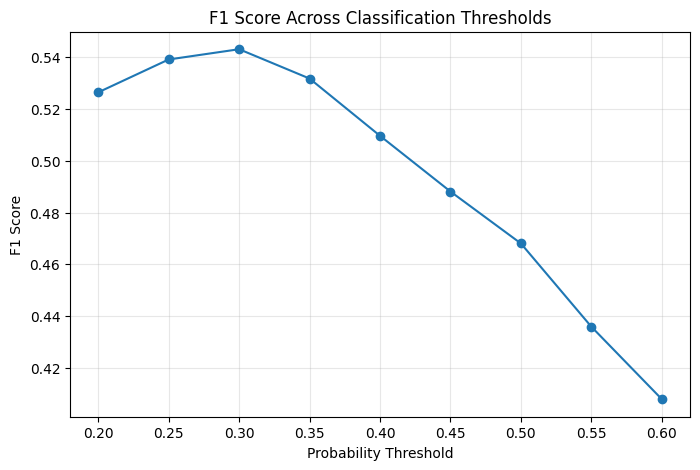

In [112]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1"],
    marker="o"
)

plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score Across Classification Thresholds")
plt.grid(alpha=0.3)
plt.show()

In [113]:
best_f1_row = threshold_results_df.loc[
    threshold_results_df["f1"].idxmax()
]

best_f1_row

threshold    0.300000
precision    0.533430
recall       0.553127
f1           0.543100
roc_auc      0.779085
pr_auc       0.555262
Name: 2, dtype: float64

### 15.6 Business Trade-off

In [114]:
threshold_results_df[
    [
        "threshold",
        "precision",
        "recall",
        "f1"
    ]
].round(4)

,threshold,precision,recall,f1
0,0.20,0.4345,0.6677,0.5264
1,0.25,0.4881,0.6021,0.5391
2,0.30,0.5334,0.5531,0.5431
3,0.35,0.5743,0.4951,0.5318
4,0.40,0.6097,0.4378,0.5096
5,0.45,0.6390,0.3949,0.4881
6,0.50,0.6630,0.3617,0.4681
7,0.55,0.6822,0.3203,0.4359
8,0.60,0.6996,0.2879,0.4079


At the default 0.50 threshold, we're catching only about 36% of actual defaults.

At 0.30, recall rises to about 55%, while precision is still about 53%.

So 0.30 is our current candidate operating threshold because it produced the highest F1 among the thresholds we tested.

But—and this is important—we're not locking 0.30 as the final production threshold yet.

The threshold is a business decision:

If missing a genuine defaulter is very costly → lower threshold may be appropriate.
If incorrectly flagging good customers is very costly → higher threshold may be appropriate.
F1 gives us a useful balanced reference, but it isn't automatically the business objective.

In [115]:
candidate_threshold = 0.30

candidate_pred = (
    random_forest_prob >= candidate_threshold
).astype(int)

candidate_cm = confusion_matrix(
    y_test,
    candidate_pred
)

print("Confusion Matrix at Threshold = 0.30")
print(candidate_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        candidate_pred
    )
)

Confusion Matrix at Threshold = 0.30
[[4031  642]
 [ 593  734]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      4673
           1       0.53      0.55      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.71      6000
weighted avg       0.80      0.79      0.80      6000



The baseline Random Forest threshold of 0.50 resulted in a recall of 36.17%. Threshold analysis showed that reducing the threshold to 0.30 increased recall to 55.31% while maintaining a precision of 53.34%, producing the highest F1 score among the evaluated thresholds. A threshold of 0.30 is therefore retained as a candidate operating point for subsequent model evaluation. The final threshold will be reconsidered after hyperparameter tuning and final model validation, since the appropriate operating point depends on the relative cost of false negatives and false positives.

## 16. Hyperparameter Tuning

### 16.1 Define the tuning space

In [116]:
rf_param_grid = {
    "classifier__n_estimators": [200, 300, 400, 500],
    "classifier__max_depth": [8, 10, 12, 15, 18, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [2, 5, 10, 20],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__class_weight": [None, "balanced"]
}

### 16.2 Configure RandomizedSearchCV

In [117]:
rf_random_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=rf_param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

### 16.3 Run hyperparameter tuning

In [118]:
rf_random_search.fit(X_train, y_train)

## 25 parameter combinations × 5 CV folds = 125 model fits.

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [8, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [2, 5, ...], ...}"
,n_iter,25
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### 16.4 Inspect the best parameters

In [119]:
print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(f"{rf_random_search.best_score_:.4f}")

Best Parameters:
{'classifier__n_estimators': 400, 'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 20, 'classifier__max_features': None, 'classifier__max_depth': 8, 'classifier__class_weight': 'balanced'}

Best Cross-Validation ROC-AUC:
0.7857


### 16.5 Evaluate the tuned model on the test set

In [120]:
tuned_random_forest = rf_random_search.best_estimator_

tuned_rf_metrics, tuned_rf_pred, tuned_rf_prob = evaluate_model(
    tuned_random_forest,
    X_test,
    y_test
)

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.49      0.60      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000


Metrics:
accuracy: 0.7722
precision: 0.4878
recall: 0.6014
f1: 0.5386
roc_auc: 0.7797
pr_auc: 0.5527


### 16.6 Compare baseline vs tuned Random Forest

In [121]:
rf_comparison = pd.DataFrame({
    "Baseline Random Forest": random_forest_metrics,
    "Tuned Random Forest": tuned_rf_metrics
}).T

rf_comparison.round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
Baseline Random Forest,0.8182,0.6630,0.3617,0.4681,0.7791,0.5553
Tuned Random Forest,0.7722,0.4878,0.6014,0.5386,0.7797,0.5527


### 16.7 Compare probability distributions

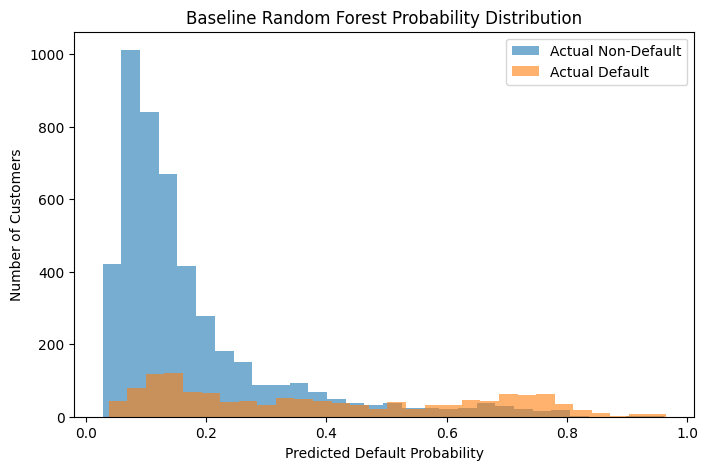

In [122]:
plt.figure(figsize=(8, 5))

plt.hist(
    random_forest_prob[y_test.values == 0],
    bins=30,
    alpha=0.6,
    label="Actual Non-Default"
)

plt.hist(
    random_forest_prob[y_test.values == 1],
    bins=30,
    alpha=0.6,
    label="Actual Default"
)

plt.xlabel("Predicted Default Probability")
plt.ylabel("Number of Customers")
plt.title("Baseline Random Forest Probability Distribution")
plt.legend()
plt.show()

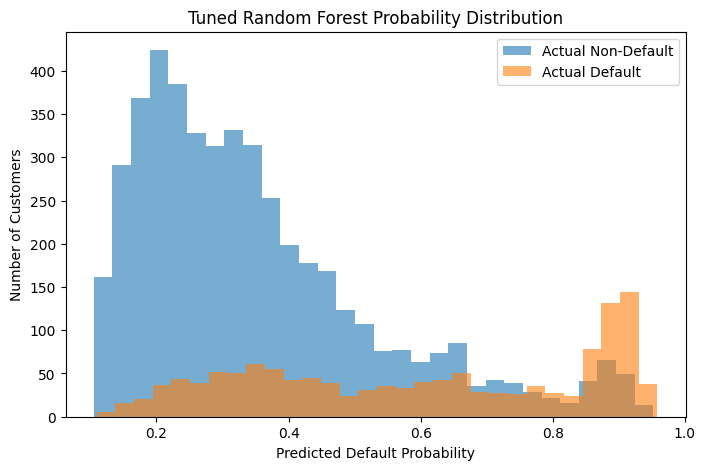

In [123]:
plt.figure(figsize=(8, 5))

plt.hist(
    tuned_rf_prob[y_test.values == 0],
    bins=30,
    alpha=0.6,
    label="Actual Non-Default"
)

plt.hist(
    tuned_rf_prob[y_test.values == 1],
    bins=30,
    alpha=0.6,
    label="Actual Default"
)

plt.xlabel("Predicted Default Probability")
plt.ylabel("Number of Customers")
plt.title("Tuned Random Forest Probability Distribution")
plt.legend()
plt.show()

## 17. Final Threshold Selection & Model Evaluation

### 17.1 Evaluate tuned model across thresholds

In [124]:
tuned_thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

tuned_threshold_results = []

for threshold in tuned_thresholds:
    y_pred_threshold = (
        tuned_rf_prob >= threshold
    ).astype(int)

    tuned_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "f1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

tuned_threshold_results_df = pd.DataFrame(
    tuned_threshold_results
)

tuned_threshold_results_df.round(4)

,threshold,precision,recall,f1
0,0.20,0.2570,0.9653,0.4059
1,0.25,0.2865,0.9088,0.4356
2,0.30,0.3153,0.8485,0.4598
3,0.35,0.3577,0.7784,0.4902
4,0.40,0.3987,0.7031,0.5089
5,0.45,0.4386,0.6458,0.5224
6,0.50,0.4878,0.6014,0.5386
7,0.55,0.5253,0.5629,0.5435
8,0.60,0.5589,0.5185,0.5379


### 17.2 Plot the tuned threshold trade-off

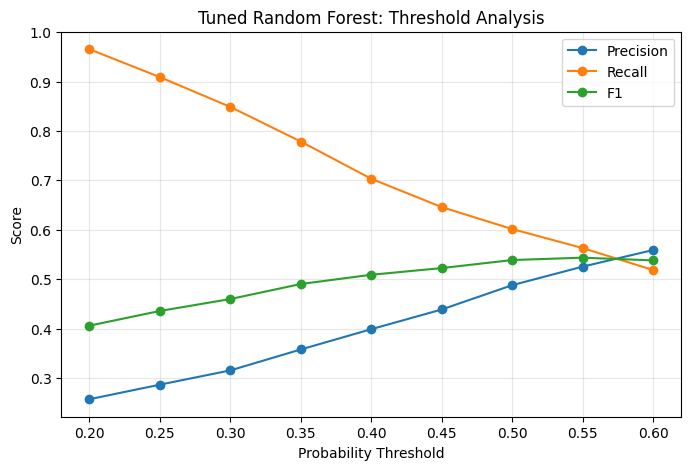

In [125]:
plt.figure(figsize=(8, 5))

plt.plot(
    tuned_threshold_results_df["threshold"],
    tuned_threshold_results_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    tuned_threshold_results_df["threshold"],
    tuned_threshold_results_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    tuned_threshold_results_df["threshold"],
    tuned_threshold_results_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Tuned Random Forest: Threshold Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 17.3 Identify candidate threshold

In [126]:
tuned_best_f1_row = tuned_threshold_results_df.loc[
    tuned_threshold_results_df["f1"].idxmax()
]

tuned_best_f1_row

threshold    0.550000
precision    0.525316
recall       0.562924
f1           0.543470
Name: 7, dtype: float64

### 17.4 Compare baseline and tuned operating points

In [127]:
threshold_comparison = pd.DataFrame({
    "Baseline RF @ 0.50": [
        random_forest_metrics["precision"],
        random_forest_metrics["recall"],
        random_forest_metrics["f1"]
    ],
    "Baseline RF @ 0.30": [
        threshold_results_df.loc[
            threshold_results_df["threshold"] == 0.30,
            "precision"
        ].iloc[0],
        threshold_results_df.loc[
            threshold_results_df["threshold"] == 0.30,
            "recall"
        ].iloc[0],
        threshold_results_df.loc[
            threshold_results_df["threshold"] == 0.30,
            "f1"
        ].iloc[0]
    ],
    "Tuned RF @ 0.50": [
        tuned_rf_metrics["precision"],
        tuned_rf_metrics["recall"],
        tuned_rf_metrics["f1"]
    ]
}, index=["precision", "recall", "f1"])

threshold_comparison.round(4)

,Baseline RF @ 0.50,Baseline RF @ 0.30,Tuned RF @ 0.50
precision,0.6630,0.5334,0.4878
recall,0.3617,0.5531,0.6014
f1,0.4681,0.5431,0.5386


### 17.5 Select candidate operating configuration

In [128]:
FINAL_THRESHOLD = 0.55

final_model = tuned_random_forest

final_probabilities = tuned_rf_prob

final_predictions = (
    final_probabilities >= FINAL_THRESHOLD
).astype(int)

final_metrics = {
    "threshold": FINAL_THRESHOLD,
    "accuracy": accuracy_score(
        y_test,
        final_predictions
    ),
    "precision": precision_score(
        y_test,
        final_predictions
    ),
    "recall": recall_score(
        y_test,
        final_predictions
    ),
    "f1": f1_score(
        y_test,
        final_predictions
    ),
    "roc_auc": roc_auc_score(
        y_test,
        final_probabilities
    ),
    "pr_auc": average_precision_score(
        y_test,
        final_probabilities
    )
}

pd.Series(final_metrics).round(4)

threshold    0.5500
accuracy     0.7908
precision    0.5253
recall       0.5629
f1           0.5435
roc_auc      0.7797
pr_auc       0.5527
dtype: float64

### 17.6 Final confusion matrix

In [129]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("Final Candidate Confusion Matrix:")
print(final_cm)

print("\nFinal Candidate Classification Report:")
print(
    classification_report(
        y_test,
        final_predictions
    )
)

Final Candidate Confusion Matrix:
[[3998  675]
 [ 580  747]]

Final Candidate Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4673
           1       0.53      0.56      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000



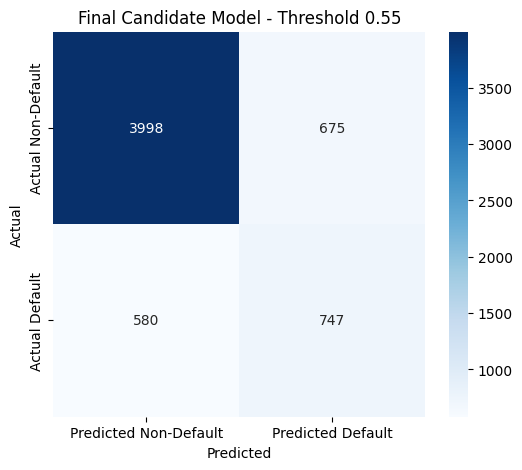

In [130]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-Default", "Predicted Default"],
    yticklabels=["Actual Non-Default", "Actual Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Final Candidate Model - Threshold {FINAL_THRESHOLD}")
plt.show()

### 17.7 Model decision document

Model selection summary

Random Forest was selected as the initial model for further investigation after achieving the strongest baseline performance across several classification metrics. Hyperparameter tuning with 5-fold cross-validation produced a configuration using class-balanced weighting and achieved a cross-validation ROC-AUC of 0.7857. On the held-out test set, the tuned model achieved a ROC-AUC of 0.7797 and PR-AUC of 0.5527.

Threshold analysis showed that a threshold of 0.55 produced the highest F1 score among the evaluated thresholds for the tuned model, with precision of 52.53% and recall of 56.29%. This threshold is therefore retained as a candidate operating threshold for subsequent model evaluation. The threshold is not treated as a universal business optimum because the relative costs of false positives and false negatives have not yet been formally defined.

The final model and threshold should be validated further before deployment.

## 18. Model Explainability — SHAP

### 18.1 Extract the trained Random Forest

In [131]:
trained_preprocessor = final_model.named_steps["preprocessor"]
trained_classifier = final_model.named_steps["classifier"]

X_test_transformed = trained_preprocessor.transform(X_test)

print(type(trained_classifier))
print(X_test_transformed.shape)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
(6000, 52)


### 18.2 Get feature names

In [132]:
feature_names = trained_preprocessor.get_feature_names_out()

print(f"Number of features: {len(feature_names)}")
print(feature_names[:20])

Number of features: 52
['numerical__credit_limit' 'numerical__age' 'numerical__repay_sep'
 'numerical__repay_aug' 'numerical__repay_jul' 'numerical__repay_jun'
 'numerical__repay_may' 'numerical__repay_apr' 'numerical__bill_sep'
 'numerical__bill_aug' 'numerical__bill_jul' 'numerical__bill_jun'
 'numerical__bill_may' 'numerical__bill_apr' 'numerical__payment_sep'
 'numerical__payment_aug' 'numerical__payment_jul'
 'numerical__payment_jun' 'numerical__payment_may'
 'numerical__payment_apr']


### 18.3 Create SHAP explainer

In [133]:
explainer = shap.TreeExplainer(
    trained_classifier
)

In [134]:
X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

print(type(shap_values))

<class 'numpy.ndarray'>


### 18.4 Global Feature Importance

In [137]:
shap_default = shap_values[:, :, 1]

mean_abs_shap = np.abs(shap_default).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

shap_importance.head(15)

,feature,mean_abs_shap
23,numerical__max_repayment_status,0.068504
26,numerical__months_with_delay,0.064107
0,numerical__credit_limit,0.032171
25,numerical__months_serious_delay,0.028694
2,numerical__repay_sep,0.026697
27,numerical__recent_repayment_status,0.021508
33,numerical__payment_to_bill_ratio,0.011530
29,numerical__bill_amount_std,0.011069
8,numerical__bill_sep,0.010469
32,numerical__max_payment_amount,0.009737


### 18.5 Visualize Global Feature Importance

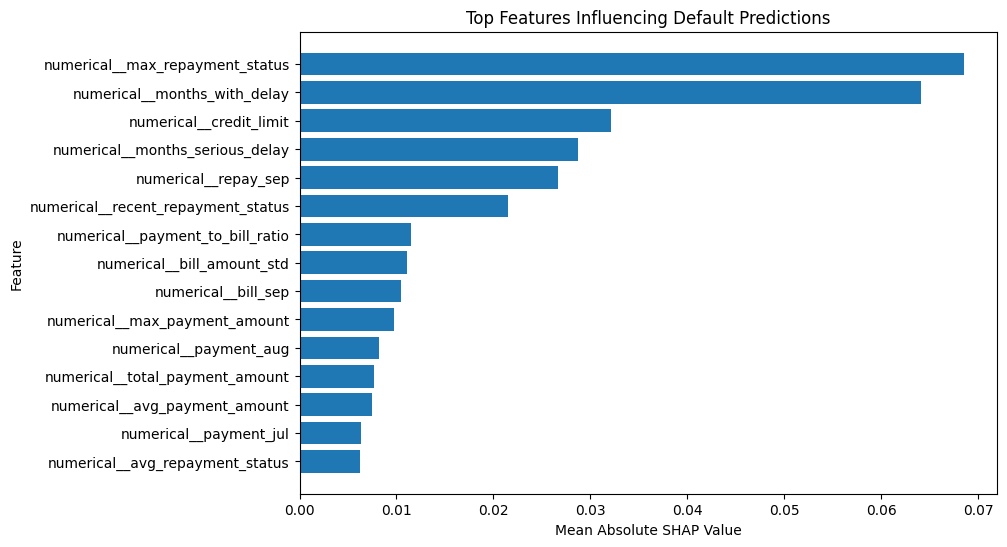

In [138]:
top_features = shap_importance.head(15).sort_values(
    "mean_abs_shap"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["mean_abs_shap"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top Features Influencing Default Predictions")
plt.show()

### 18.6 Individual Prediction Explanation

In [139]:
sample_index = 0

sample_probability = final_probabilities[sample_index]

print(
    f"Predicted default probability: "
    f"{sample_probability:.4f}"
)

print(
    f"Actual outcome: "
    f"{y_test.iloc[sample_index]}"
)

Predicted default probability: 0.2683
Actual outcome: 0


In [140]:
sample_shap = shap_default[sample_index]

sample_explanation = (
    pd.DataFrame({
        "feature": feature_names,
        "shap_value": sample_shap
    })
    .sort_values(
        "shap_value",
        key=abs,
        ascending=False
    )
)

sample_explanation.head(10)

,feature,shap_value
26,numerical__months_with_delay,-0.049309
23,numerical__max_repayment_status,-0.048671
0,numerical__credit_limit,0.031902
33,numerical__payment_to_bill_ratio,-0.021829
25,numerical__months_serious_delay,-0.018482
29,numerical__bill_amount_std,-0.015747
2,numerical__repay_sep,-0.012396
10,numerical__bill_jul,-0.012225
14,numerical__payment_sep,-0.011278
27,numerical__recent_repayment_status,-0.009806


### 18.7 SHAP Summary Plot

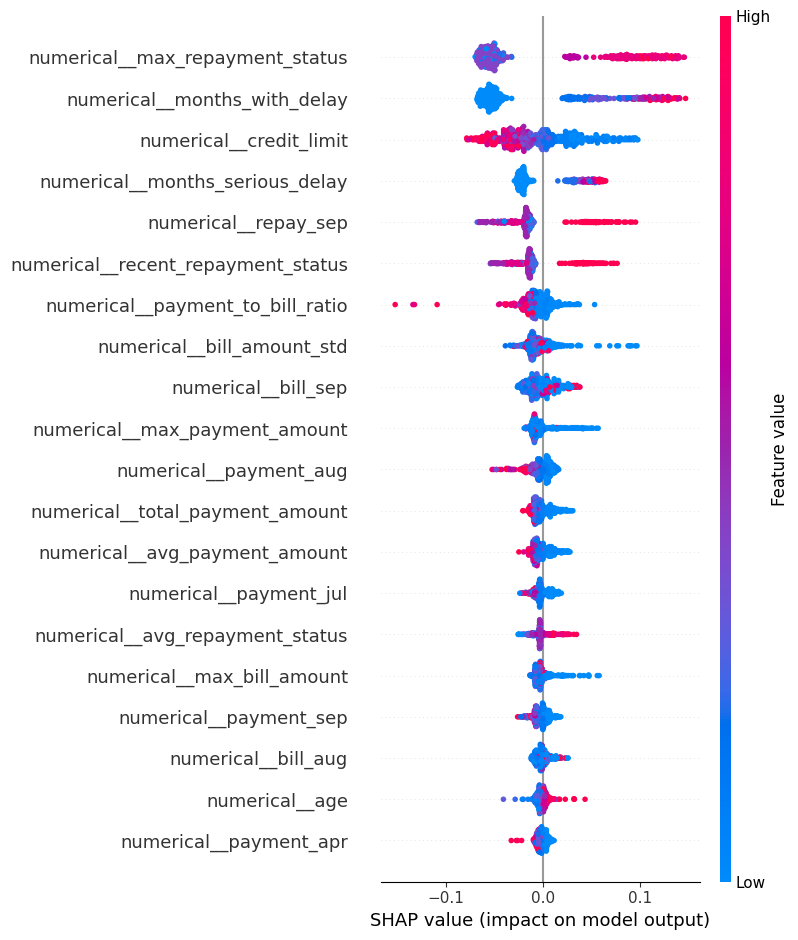

In [141]:
shap.summary_plot(
    shap_default,
    X_shap,
    feature_names=feature_names,
    show=True
)

## 19. Risk Bands & Business Logic

### 19.1 Define risk bands is our next cell.

In [142]:
RISK_BANDS = {
    "LOW": {
        "min_probability": 0.00,
        "max_probability": 0.30
    },
    "MEDIUM": {
        "min_probability": 0.30,
        "max_probability": 0.55
    },
    "HIGH": {
        "min_probability": 0.55,
        "max_probability": 1.00
    }
}

RISK_BANDS

{'LOW': {'min_probability': 0.0, 'max_probability': 0.3},
 'MEDIUM': {'min_probability': 0.3, 'max_probability': 0.55},
 'HIGH': {'min_probability': 0.55, 'max_probability': 1.0}}

### 19.2 Create Risk-Band Function

In [143]:
def get_risk_band(default_probability):
    """
    Convert default probability into a project-defined risk band.
    """

    if default_probability < 0.30:
        return "LOW"

    elif default_probability < 0.55:
        return "MEDIUM"

    else:
        return "HIGH"

In [144]:
test_probabilities = [
    0.10,
    0.29,
    0.30,
    0.45,
    0.54,
    0.55,
    0.80
]

for probability in test_probabilities:
    print(
        f"{probability:.2f} → "
        f"{get_risk_band(probability)}"
    )

0.10 → LOW
0.29 → LOW
0.30 → MEDIUM
0.45 → MEDIUM
0.54 → MEDIUM
0.55 → HIGH
0.80 → HIGH


### 19.3 Apply Risk Bands to Test Predictions

In [145]:
risk_bands = pd.Series(
    final_probabilities
).apply(get_risk_band)

risk_band_distribution = (
    risk_bands
    .value_counts()
    .reindex(["LOW", "MEDIUM", "HIGH"], fill_value=0)
)

risk_band_distribution

LOW       2429
MEDIUM    2149
HIGH      1422
Name: count, dtype: int64

In [146]:
risk_band_percentage = (
    risk_band_distribution
    .div(len(risk_bands))
    .mul(100)
    .round(2)
)

risk_band_percentage

LOW       40.48
MEDIUM    35.82
HIGH      23.70
Name: count, dtype: float64

### 19.4 Validate Risk-Band Logic

In [147]:
risk_band_validation = pd.DataFrame({
    "default_probability": final_probabilities,
    "risk_band": risk_bands
})

risk_band_validation.groupby(
    "risk_band"
)["default_probability"].agg(
    ["min", "max", "mean", "count"]
).reindex(
    ["LOW", "MEDIUM", "HIGH"]
)

,min,max,mean,count
risk_band,,,,
LOW,0.105193,0.299800,0.211351,2429
MEDIUM,0.300009,0.549911,0.396855,2149
HIGH,0.550656,0.958504,0.758689,1422


### 19.5 Add Risk Descriptions

In [148]:
RISK_DESCRIPTIONS = {
    "LOW": "Lower predicted probability of default.",
    "MEDIUM": "Moderate predicted probability of default.",
    "HIGH": "Higher predicted probability of default."
}

def get_risk_description(risk_band):
    return RISK_DESCRIPTIONS[risk_band]

In [149]:
for band in ["LOW", "MEDIUM", "HIGH"]:
    print(
        f"{band}: "
        f"{get_risk_description(band)}"
    )

LOW: Lower predicted probability of default.
MEDIUM: Moderate predicted probability of default.
HIGH: Higher predicted probability of default.


### 19.6 Create Application-Ready Risk Output

In [150]:
def build_risk_output(default_probability):
    risk_band = get_risk_band(default_probability)

    return {
        "default_probability": round(
            float(default_probability),
            4
        ),
        "risk_band": risk_band,
        "risk_description": get_risk_description(
            risk_band
        )
    }

In [151]:
build_risk_output(0.73)

{'default_probability': 0.73,
 'risk_band': 'HIGH',
 'risk_description': 'Higher predicted probability of default.'}

### 19.7 Document the Business Logic

Risk Band Logic

The model's predicted probability of default is converted into three application-level risk bands: LOW, MEDIUM, and HIGH. The project uses configurable probability boundaries of 0.30 and 0.55. These thresholds are based on the model's threshold analysis and are treated as candidate operating boundaries rather than universal credit-risk standards. Keeping the thresholds in explicit configuration allows them to be changed independently of the trained model as business requirements evolve.

## 20. Model Serialization

### 20.1 Create Model Directory

In [153]:
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR

WindowsPath('d:/credit-risk-ml-platform/models')

### 20.2 Save the Trained Model

In [154]:
MODEL_PATH = MODEL_DIR / "credit_risk_model.joblib"

joblib.dump(
    final_model,
    MODEL_PATH
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: d:\credit-risk-ml-platform\models\credit_risk_model.joblib


### 20.3 Save Model Configuration

In [155]:
MODEL_CONFIG = {
    "model_version": "v1.0",
    "model_type": "RandomForestClassifier",
    "candidate_threshold": FINAL_THRESHOLD,
    "risk_band_boundaries": {
        "low_max": 0.30,
        "medium_max": 0.55
    }
}

CONFIG_PATH = MODEL_DIR / "model_config.joblib"

joblib.dump(
    MODEL_CONFIG,
    CONFIG_PATH
)

print(f"Configuration saved to: {CONFIG_PATH}")

Configuration saved to: d:\credit-risk-ml-platform\models\model_config.joblib


### 20.4 Reload the Model

In [156]:
loaded_model = joblib.load(
    MODEL_PATH
)

loaded_config = joblib.load(
    CONFIG_PATH
)

print("Model loaded successfully.")
print("Configuration loaded successfully.")

Model loaded successfully.
Configuration loaded successfully.


### 20.5 Validate the Reloaded Model

In [157]:
original_probability = final_model.predict_proba(
    X_test.iloc[[0]]
)[:, 1][0]

loaded_probability = loaded_model.predict_proba(
    X_test.iloc[[0]]
)[:, 1][0]

print(
    f"Original probability: {original_probability:.10f}"
)

print(
    f"Loaded probability:   {loaded_probability:.10f}"
)

print(
    "\nPredictions match:",
    np.isclose(
        original_probability,
        loaded_probability
    )
)

Original probability: 0.2683374916
Loaded probability:   0.2683374916

Predictions match: True


### 20.6 Validate Configuration

In [158]:
print(loaded_config)

{'model_version': 'v1.0', 'model_type': 'RandomForestClassifier', 'candidate_threshold': 0.55, 'risk_band_boundaries': {'low_max': 0.3, 'medium_max': 0.55}}


## 21. FastAPI Prediction Service